# PCA — Weighted Survey Matrix vs Cellular Matrix

Re-examines the survey ↔ cellular comparison of `THS_2018_MTX_weighted_vs_cellular.ipynb` with **Principal Component Analysis**. The earlier notebook scored cell-by-cell agreement (RMSE, Pearson r ≈ 0.855 at superzone level); PCA instead asks a structural question: are the two matrices built from the **same dominant destination-choice patterns**, and where exactly do their structures part ways?

**Framing.** Each origin zone is an observation; its row-normalized destination-share profile is the feature vector. Principal components are then the dominant patterns of destination choice across origins, and the comparison happens between the two matrices' component structures rather than between individual cells.

**Inputs** — saved outputs of the earlier pipeline steps:
- superzone level (36 `SZ_NEW` zones): `Output/prob_sz_cellular.csv`, `Output/prob_sz_10_weighted.csv`, `Output/prob_sz_20_weighted.csv`
- TAZ level (778 zones): `Output/matrix_10_weighted.csv`, `Output/matrix_20_weighted.csv` (raw `wf_new`-weighted counts, re-normalized here after restriction to the study TAZ set), `Output/prob_matrix_cellular.csv`

**Benchmark convention.** Every survey-vs-cellular statistic is judged against two anchors: the same statistic between **Day 10 and Day 20** of the survey (the survey's internal-consistency ceiling — no comparison can be expected to beat the survey's agreement with itself) and an explicit **chance level** (analytic or permutation-based).

## Test design

| # | Test | Question | Statistic | Benchmark |
|---|------|----------|-----------|-----------|
| T1 | Dimensionality | Do the two matrices encode comparably complex destination structure? | scree curve, n₈₀/n₉₀, participation ratio | Day 10 vs Day 20 |
| T2 | Subspace overlap | Do they span the same dominant patterns? | mean cos² of principal angles between top-k loading subspaces | day ceiling, chance k/p, permuted-geography null (p-value) |
| T3 | Cross-projection | How much of one matrix do the other's components explain? | relative cross-explained variance RCEV(k) | day ceiling |
| T4 | Component matching | Which individual patterns correspond? | Tucker congruence, Hungarian-matched | — |
| T5 | Divergence map | Where and in what direction do the sources diverge? | joint-PCA displacement per zone; sign-flip test for a common bias direction | day-to-day displacement |
| T6 | Divergence anatomy | Is the disagreement the intra-zone (diagonal) split? | diagonal share of ‖survey−cellular‖²; re-run of T2/T3 with diagonal removed | day ceiling |

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.linalg import subspace_angles
from scipy.optimize import linear_sum_assignment

rng = np.random.default_rng(42)

# palette (repo convention: blue = Day 10, orange = Day 20; aqua = cellular)
BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'
INK, INK2, MUTED, GRID, AXIS = '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7'
CMAP_SEQ = LinearSegmentedColormap.from_list(
    'seq_blue', ['#fcfcfb', '#cde2fb', '#9ec5f4', '#6da7ec', '#3987e5', '#256abf', '#184f95', '#0d366b'])
CMAP_DIV = LinearSegmentedColormap.from_list(
    'div_blue_red', ['#0d366b', '#2a78d6', '#86b6ef', '#f0efec', '#f2a29e', '#e34948', '#7f1e1e'])

def style_ax(ax, title=None, xlabel=None, ylabel=None):
    ax.grid(True, color=GRID, linewidth=0.6)
    ax.set_axisbelow(True)
    for s in ax.spines.values():
        s.set_color(AXIS)
    ax.tick_params(colors=INK2, labelsize=9)
    if title: ax.set_title(title, color=INK, fontsize=12)
    if xlabel: ax.set_xlabel(xlabel, color=INK2, fontsize=10)
    if ylabel: ax.set_ylabel(ylabel, color=INK2, fontsize=10)

os.makedirs('Output/figures', exist_ok=True)
def save_show(fig, name):
    fig.savefig(f'Output/figures/{name}', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()

## 1. Data — load and align

Superzone probability matrices are already row-normalized and share one index. At TAZ level the saved weighted matrices include a small share of trips ending outside the 778 study TAZs, so the raw counts are restricted to the cellular TAZ set and re-normalized; origins are kept only where **both** survey days observed at least one trip, so all three matrices describe the same observations.

In [2]:
sz_cell = pd.read_csv('Output/prob_sz_cellular.csv', index_col=0)
sz_s10 = pd.read_csv('Output/prob_sz_10_weighted.csv', index_col=0)
sz_s20 = pd.read_csv('Output/prob_sz_20_weighted.csv', index_col=0)
for m in (sz_cell, sz_s10, sz_s20):
    m.columns = m.columns.astype(int)
assert list(sz_cell.index) == list(sz_s10.index) == list(sz_s20.index)

taz_cell_prob = pd.read_csv('Output/prob_matrix_cellular.csv', index_col=0)
taz_cell_prob.columns = taz_cell_prob.columns.astype(int)
standard_tazs = taz_cell_prob.index

def load_taz_survey(path):
    m = pd.read_csv(path, index_col=0)
    m.columns = m.columns.astype(int)
    total = m.values.sum()
    m = m.reindex(index=standard_tazs, columns=standard_tazs, fill_value=0)
    return m, m.values.sum() / total

cnt10, keep10 = load_taz_survey('Output/matrix_10_weighted.csv')
cnt20, keep20 = load_taz_survey('Output/matrix_20_weighted.csv')
common = standard_tazs[(cnt10.sum(axis=1) > 0).values & (cnt20.sum(axis=1) > 0).values]

def rownorm(m):
    return m.div(m.sum(axis=1), axis=0)

taz_s10 = rownorm(cnt10.loc[common])
taz_s20 = rownorm(cnt20.loc[common])
taz_cell = taz_cell_prob.loc[common]
assert np.allclose(taz_s10.sum(axis=1), 1) and np.allclose(taz_cell.sum(axis=1), 1)

print(f"share of expanded survey trips inside the 778-TAZ set: Day 10 {keep10:.3f}, Day 20 {keep20:.3f}")
print(f"superzone matrices: {sz_cell.shape};  TAZ matrices: {len(common)} origins x {len(standard_tazs)} destinations")

share of expanded survey trips inside the 778-TAZ set: Day 10 0.989, Day 20 0.988
superzone matrices: (36, 36);  TAZ matrices: 624 origins x 778 destinations


In [3]:
# PCA machinery, shared by all tests
def pca(P):
    X = np.asarray(P, dtype=float)
    Xc = X - X.mean(axis=0)
    U, s, Vt = np.linalg.svd(Xc, full_matrices=False)
    lam = s ** 2 / (X.shape[0] - 1)
    return {'V': Vt.T, 'lam': lam, 'evr': lam / lam.sum(), 'scores': U * s}

def n_comp(evr, thr):
    return int(np.searchsorted(np.cumsum(evr), thr) + 1)

def part_ratio(lam):
    # effective number of components: (sum lambda)^2 / sum lambda^2
    return float(lam.sum() ** 2 / (lam ** 2).sum())

def mean_cos2(Va, Vb, k):
    # subspace overlap in [0, 1]; for a random k-dim subspace in R^p, E = k/p
    return float(np.mean(np.cos(subspace_angles(Va[:, :k], Vb[:, :k])) ** 2))

def rcev(P_target, pc_target, pc_source, k):
    # variance of target captured by the source's top-k PCs, relative to the
    # target's own top-k (the optimum any k-dim basis can reach)
    Xc = np.asarray(P_target, float) - np.asarray(P_target, float).mean(axis=0)
    cap = ((Xc @ pc_source['V'][:, :k]) ** 2).sum() / (Xc.shape[0] - 1)
    return float(cap / pc_target['lam'][:k].sum())

P_SZ = {'cellular': sz_cell, 'survey d10': sz_s10, 'survey d20': sz_s20}
P_TAZ = {'cellular': taz_cell, 'survey d10': taz_s10, 'survey d20': taz_s20}
PC_SZ = {name: pca(P) for name, P in P_SZ.items()}
PC_TAZ = {name: pca(P) for name, P in P_TAZ.items()}

## 2. T1 — Dimensionality: how complex is each matrix's destination structure?

If the survey and the cellular data described the same behavior with the same fidelity, their variance spectra would look alike. A genuinely richer structure needs more components; **sampling noise also inflates dimensionality**, because noise spreads variance evenly across many directions — so a much flatter survey spectrum is the signature of sparsity, not of extra behavioral structure.

In [4]:
rows = []
for lvl, PC in [('SZ', PC_SZ), ('TAZ', PC_TAZ)]:
    for name, pc in PC.items():
        rows.append({'level': lvl, 'matrix': name, 'PC1 share': pc['evr'][0],
                     'n80': n_comp(pc['evr'], .8), 'n90': n_comp(pc['evr'], .9),
                     'participation ratio': part_ratio(pc['lam'])})
t1 = pd.DataFrame(rows).set_index(['level', 'matrix'])

# headline k for later tests: components covering 80% of cellular variance
kSZ = n_comp(PC_SZ['cellular']['evr'], .8)
kTAZ = n_comp(PC_TAZ['cellular']['evr'], .8)
print(f"headline subspace dimension (80% of cellular variance): k = {kSZ} at SZ, k = {kTAZ} at TAZ")
t1.round(3)

headline subspace dimension (80% of cellular variance): k = 12 at SZ, k = 52 at TAZ


PC1 share  n80  n90  participation ratio
level matrix                                              
SZ    cellular        0.139   12   16               13.104
      survey d10      0.052   23   28               30.057
      survey d20      0.052   23   28               29.890
TAZ   cellular        0.065   52   87               42.381
      survey d10      0.011  200  273              248.534
      survey d20      0.020  195  268              226.566

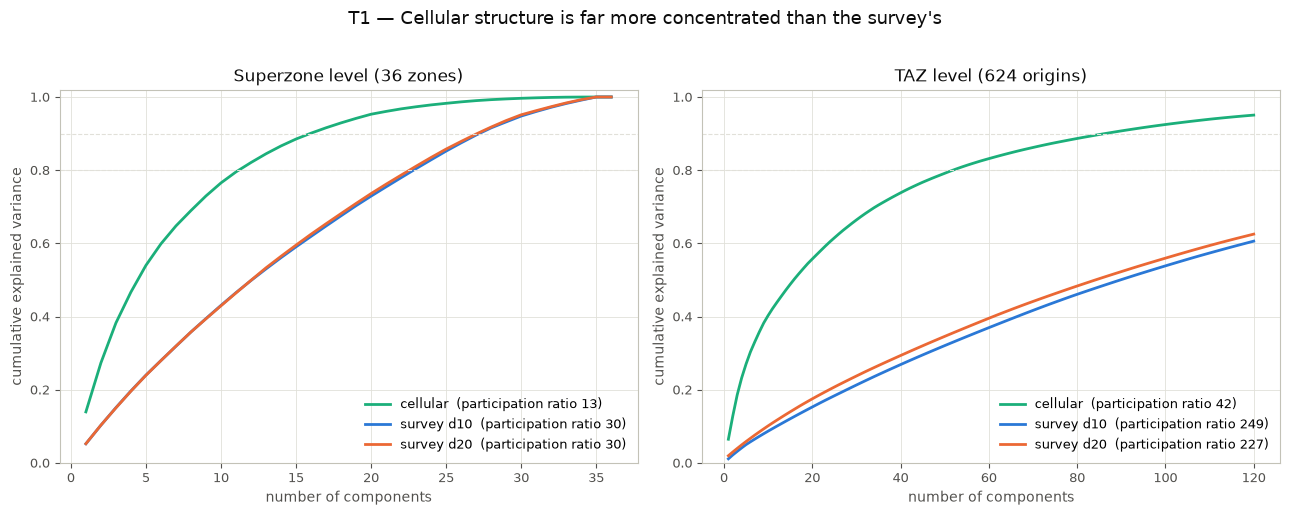

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='white')
panels = [('Superzone level (36 zones)', PC_SZ, 36), ('TAZ level (624 origins)', PC_TAZ, 120)]
for ax, (title, PC, pmax) in zip(axes, panels):
    for name, color in [('cellular', AQUA), ('survey d10', BLUE), ('survey d20', ORANGE)]:
        cum = np.cumsum(PC[name]['evr'])[:pmax]
        pr = part_ratio(PC[name]['lam'])
        ax.plot(range(1, len(cum) + 1), cum, color=color, linewidth=2,
                label=f"{name}  (participation ratio {pr:.0f})")
    for thr in (0.8, 0.9):
        ax.axhline(thr, color=GRID, linewidth=0.8, linestyle='--')
    ax.set_ylim(0, 1.02)
    style_ax(ax, title, 'number of components', 'cumulative explained variance')
    ax.legend(frameon=False, loc='lower right', fontsize=9)
fig.suptitle('T1 — Cellular structure is far more concentrated than the survey\'s',
             color=INK, fontsize=13, y=1.02)
plt.tight_layout()
save_show(fig, 'pca_scree.png')

## 3. T2 — Subspace overlap: do they span the same dominant patterns?

The top-k component loadings of each matrix span a k-dimensional subspace of destination space. The **principal angles** between the two subspaces measure how well one set of patterns can be rotated onto the other; mean cos² of those angles is 1 for identical subspaces and averages k/p for unrelated ones.

**Permutation test.** The null of "similar internal structure, but no geographic correspondence" is built by consistently relabeling the destination zones of the survey matrix (a random permutation of the loading rows) — this preserves the survey's entire spectrum and only destroys the zone-to-zone alignment with cellular.

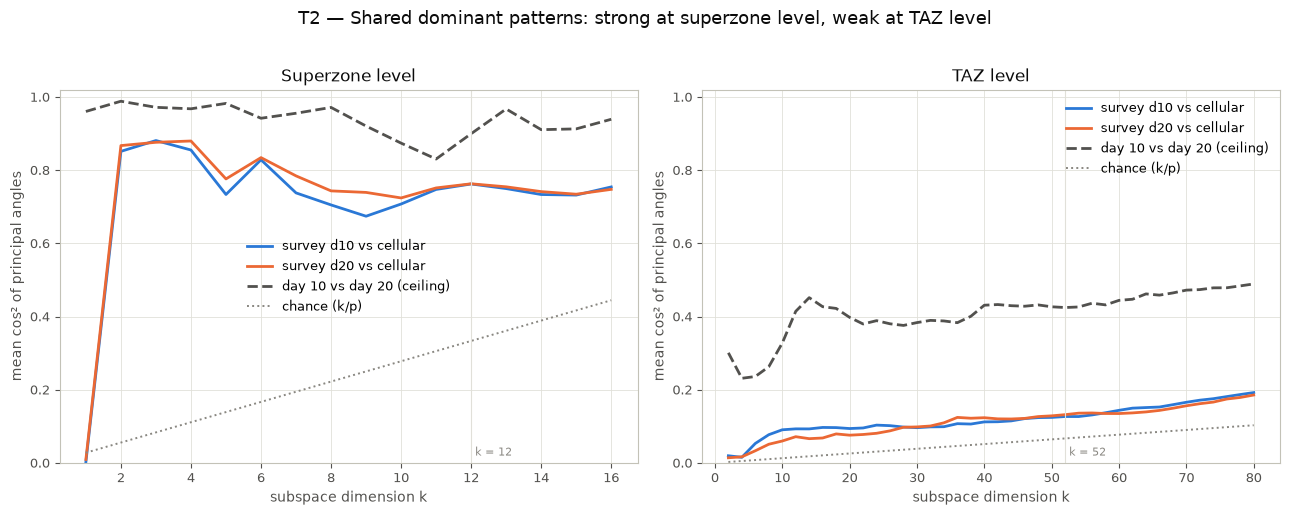

In [6]:
ks_sz, ks_taz = range(1, 17), range(2, 81, 2)
pairs = [('survey d10', 'cellular', BLUE), ('survey d20', 'cellular', ORANGE),
         ('survey d10', 'survey d20', INK2)]

def overlap_curves(PC, ks):
    return {(a, b): [mean_cos2(PC[a]['V'], PC[b]['V'], k) for k in ks] for a, b, _ in pairs}

ov_sz, ov_taz = overlap_curves(PC_SZ, ks_sz), overlap_curves(PC_TAZ, ks_taz)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='white')
for ax, (title, ov, ks, p, khead) in zip(axes, [
        ('Superzone level', ov_sz, ks_sz, 36, kSZ), ('TAZ level', ov_taz, ks_taz, 778, kTAZ)]):
    for (a, b, color) in pairs:
        ls = '--' if a == 'survey d10' and b == 'survey d20' else '-'
        lbl = 'day 10 vs day 20 (ceiling)' if ls == '--' else f'{a} vs {b}'
        ax.plot(list(ks), ov[(a, b)], color=color, linewidth=2, linestyle=ls, label=lbl)
    ax.plot(list(ks), [k / p for k in ks], color=MUTED, linewidth=1.4, linestyle=':',
            label='chance (k/p)')
    ax.axvline(khead, color=GRID, linewidth=0.8)
    ax.text(khead, 0.02, f' k = {khead}', color=MUTED, fontsize=8)
    ax.set_ylim(0, 1.02)
    style_ax(ax, title, 'subspace dimension k', 'mean cos² of principal angles')
    ax.legend(frameon=False, loc='center' if p == 36 else 'upper right', fontsize=9)
fig.suptitle('T2 — Shared dominant patterns: strong at superzone level, weak at TAZ level',
             color=INK, fontsize=13, y=1.02)
plt.tight_layout()
save_show(fig, 'pca_subspace_overlap.png')

SZ: observed 0.762, ceiling 0.900, null mean 0.340 (max 0.524 in 2000 perms), p = 0.0005


TAZ: observed 0.127, ceiling 0.425, null mean 0.067 (max 0.100 in 500 perms), p = 0.0020


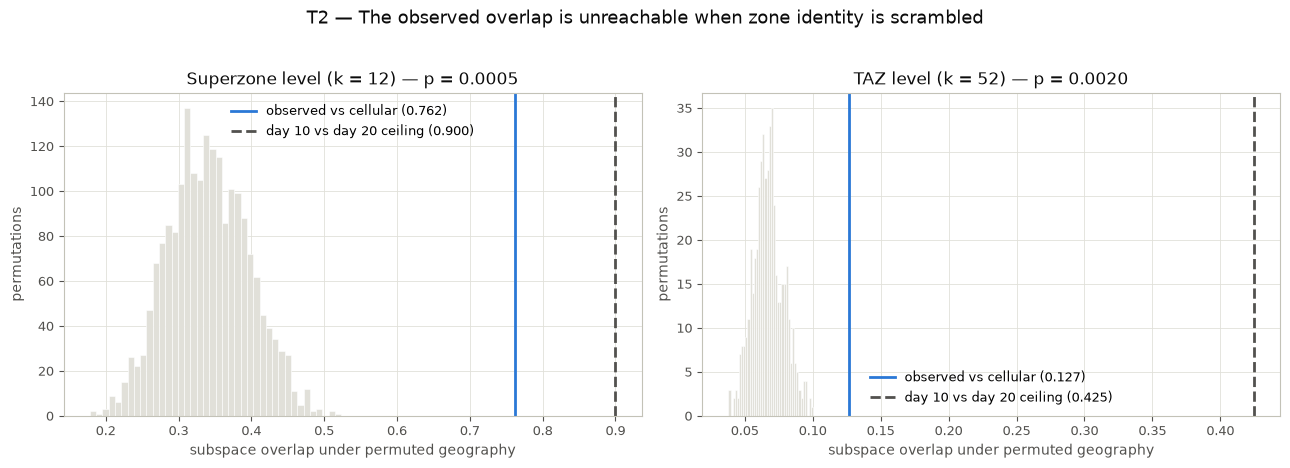

In [7]:
def perm_null(Vs, Vc, k, n_perm, seed=0):
    r = np.random.default_rng(seed)
    p = Vs.shape[0]
    return np.array([mean_cos2(Vs[r.permutation(p)], Vc, k) for _ in range(n_perm)])

perm = {}
for lvl, PC, k, n_perm in [('SZ', PC_SZ, kSZ, 2000), ('TAZ', PC_TAZ, kTAZ, 500)]:
    null = perm_null(PC['survey d10']['V'], PC['cellular']['V'], k, n_perm)
    obs = mean_cos2(PC['survey d10']['V'], PC['cellular']['V'], k)
    ceil = mean_cos2(PC['survey d10']['V'], PC['survey d20']['V'], k)
    pval = (1 + (null >= obs).sum()) / (1 + len(null))
    perm[lvl] = dict(null=null, obs=obs, ceil=ceil, p=pval, k=k)
    print(f"{lvl}: observed {obs:.3f}, ceiling {ceil:.3f}, null mean {null.mean():.3f} "
          f"(max {null.max():.3f} in {n_perm} perms), p = {pval:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), facecolor='white')
for ax, lvl, title in zip(axes, ['SZ', 'TAZ'], ['Superzone level', 'TAZ level']):
    d = perm[lvl]
    ax.hist(d['null'], bins=40, color=GRID, edgecolor='white', linewidth=0.4)
    ax.axvline(d['obs'], color=BLUE, linewidth=2,
               label=f"observed vs cellular ({d['obs']:.3f})")
    ax.axvline(d['ceil'], color=INK2, linewidth=2, linestyle='--',
               label=f"day 10 vs day 20 ceiling ({d['ceil']:.3f})")
    style_ax(ax, f"{title} (k = {d['k']}) — p = {d['p']:.4f}",
             'subspace overlap under permuted geography', 'permutations')
    ax.legend(frameon=False, fontsize=9)
fig.suptitle('T2 — The observed overlap is unreachable when zone identity is scrambled',
             color=INK, fontsize=13, y=1.03)
plt.tight_layout()
save_show(fig, 'pca_perm_null.png')

## 4. T3 — Cross-projection: how well do one matrix's components describe the other?

RCEV(k) projects one matrix onto the *other's* top-k components and divides the captured variance by what the matrix's **own** top-k components capture (the best any k-dimensional basis can do). RCEV = 1 means the other source's patterns are a perfect substitute for the matrix's own.

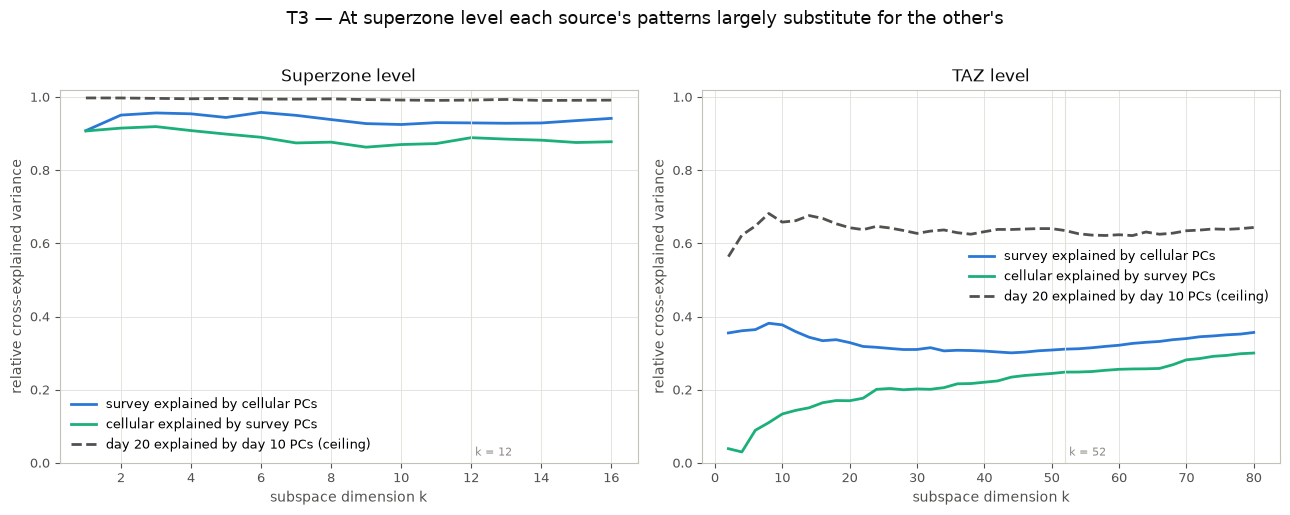

SZ (k = 12): survey|cellular 0.929, cellular|survey 0.889, ceiling 0.992
TAZ (k = 52): survey|cellular 0.311, cellular|survey 0.248, ceiling 0.635


In [8]:
cross = [('survey d10', 'cellular', BLUE, '-', 'survey explained by cellular PCs'),
         ('cellular', 'survey d10', AQUA, '-', 'cellular explained by survey PCs'),
         ('survey d20', 'survey d10', INK2, '--', 'day 20 explained by day 10 PCs (ceiling)')]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='white')
for ax, (title, P, PC, ks, khead) in zip(axes, [
        ('Superzone level', P_SZ, PC_SZ, ks_sz, kSZ), ('TAZ level', P_TAZ, PC_TAZ, ks_taz, kTAZ)]):
    for tgt, src, color, ls, lbl in cross:
        vals = [rcev(P[tgt], PC[tgt], PC[src], k) for k in ks]
        ax.plot(list(ks), vals, color=color, linewidth=2, linestyle=ls, label=lbl)
    ax.axvline(khead, color=GRID, linewidth=0.8)
    ax.text(khead, 0.02, f' k = {khead}', color=MUTED, fontsize=8)
    ax.set_ylim(0, 1.02)
    style_ax(ax, title, 'subspace dimension k', 'relative cross-explained variance')
    ax.legend(frameon=False, loc='lower left' if khead == kSZ else 'center right', fontsize=9)
fig.suptitle('T3 — At superzone level each source\'s patterns largely substitute for the other\'s',
             color=INK, fontsize=13, y=1.02)
plt.tight_layout()
save_show(fig, 'pca_cross_projection.png')

for lvl, P, PC, k in [('SZ', P_SZ, PC_SZ, kSZ), ('TAZ', P_TAZ, PC_TAZ, kTAZ)]:
    print(f"{lvl} (k = {k}): survey|cellular {rcev(P['survey d10'], PC['survey d10'], PC['cellular'], k):.3f}, "
          f"cellular|survey {rcev(P['cellular'], PC['cellular'], PC['survey d10'], k):.3f}, "
          f"ceiling {rcev(P['survey d20'], PC['survey d20'], PC['survey d10'], k):.3f}")

## 5. T4 — Component matching: which patterns correspond?

Tucker congruence (the dot product of unit-norm loading vectors) between the top 6 superzone components of each source, matched one-to-one with the Hungarian algorithm. |φ| ≥ 0.85 is conventionally read as "the same component", 0.65–0.85 as similar.

survey PC1 <-> cellular PC2: |congruence| = 0.946
survey PC2 <-> cellular PC1: |congruence| = 0.891
survey PC3 <-> cellular PC3: |congruence| = 0.890
survey PC5 <-> cellular PC6: |congruence| = 0.851
survey PC4 <-> cellular PC4: |congruence| = 0.820
survey PC6 <-> cellular PC5: |congruence| = 0.641


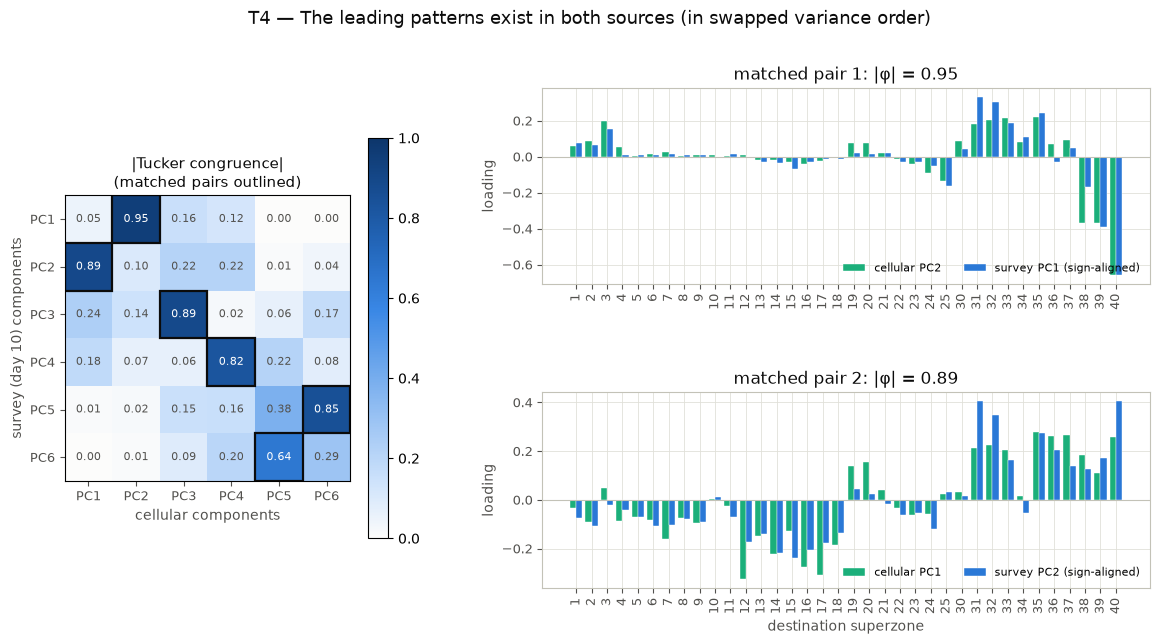

In [9]:
kc = 6
C = PC_SZ['survey d10']['V'][:, :kc].T @ PC_SZ['cellular']['V'][:, :kc]
ri, ci = linear_sum_assignment(-np.abs(C))
match = sorted(zip(ri, ci), key=lambda x: -abs(C[x[0], x[1]]))
for i, j in match:
    print(f"survey PC{i+1} <-> cellular PC{j+1}: |congruence| = {abs(C[i, j]):.3f}")

sz_ids = sz_cell.index.to_numpy()
fig = plt.figure(figsize=(14, 6.5), facecolor='white')
gs = fig.add_gridspec(2, 2, width_ratios=[1, 1.7], hspace=0.55, wspace=0.25)

ax = fig.add_subplot(gs[:, 0])
im = ax.imshow(np.abs(C), cmap=CMAP_SEQ, vmin=0, vmax=1)
for i in range(kc):
    for j in range(kc):
        v = abs(C[i, j])
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8,
                color='white' if v > 0.55 else INK2)
for i, j in zip(ri, ci):
    ax.add_patch(plt.Rectangle((j - .5, i - .5), 1, 1, fill=False, edgecolor=INK, linewidth=1.6))
ax.set_xticks(range(kc), [f'PC{j+1}' for j in range(kc)])
ax.set_yticks(range(kc), [f'PC{i+1}' for i in range(kc)])
ax.set_xlabel('cellular components', color=INK2, fontsize=10)
ax.set_ylabel('survey (day 10) components', color=INK2, fontsize=10)
ax.set_title('|Tucker congruence|\n(matched pairs outlined)', color=INK, fontsize=11)
ax.tick_params(colors=INK2, labelsize=9)
fig.colorbar(im, ax=ax, shrink=0.8)

x = np.arange(len(sz_ids))
for row, (i, j) in enumerate(match[:2]):
    ax = fig.add_subplot(gs[row, 1])
    sgn = np.sign(C[i, j])
    ax.bar(x - 0.2, PC_SZ['cellular']['V'][:, j], width=0.4, color=AQUA,
           edgecolor='white', linewidth=0.3, label=f'cellular PC{j+1}')
    ax.bar(x + 0.2, sgn * PC_SZ['survey d10']['V'][:, i], width=0.4, color=BLUE,
           edgecolor='white', linewidth=0.3, label=f'survey PC{i+1} (sign-aligned)')
    ax.set_xticks(x, sz_ids, fontsize=6.5, rotation=90)
    style_ax(ax, f'matched pair {row+1}: |φ| = {abs(C[i, j]):.2f}',
             'destination superzone' if row == 1 else None, 'loading')
    ax.axhline(0, color=AXIS, linewidth=0.8)
    ax.legend(frameon=False, fontsize=8, loc='lower right', ncols=2)
fig.suptitle('T4 — The leading patterns exist in both sources (in swapped variance order)',
             color=INK, fontsize=13, y=1.0)
save_show(fig, 'pca_component_match.png')

In [10]:
# what do the leading components mean? correlate each component's origin scores
# with the origin's own self-containment (share of trips staying inside the zone)
for name in ['cellular', 'survey d10']:
    P, pc = P_SZ[name], PC_SZ[name]
    for j in range(3):
        r = np.corrcoef(pc['scores'][:, j], np.diag(P.values))[0, 1]
        print(f"{name} PC{j+1}: corr(score, self-containment) = {r:+.3f}, "
              f"variance share {pc['evr'][j]:.3f}")

cellular PC1: corr(score, self-containment) = +0.763, variance share 0.139
cellular PC2: corr(score, self-containment) = -0.005, variance share 0.134
cellular PC3: corr(score, self-containment) = -0.102, variance share 0.109
survey d10 PC1: corr(score, self-containment) = -0.056, variance share 0.052
survey d10 PC2: corr(score, self-containment) = -0.756, variance share 0.051
survey d10 PC3: corr(score, self-containment) = +0.105, variance share 0.048


## 6. T5 — Joint PCA: where do the sources diverge?

Both sources' origin profiles are projected into one common component space (PCA of the stacked 72 × 36 data). Each superzone appears twice — its cellular profile and its survey profile — and the connecting segment is that zone's structural divergence. Two statistics summarize the picture:

- **displacement ratio** — mean profile distance survey↔cellular against the day-10↔day-20 distance (how far beyond survey noise the divergence is);
- **sign-flip test** — is the divergence one *common direction* in destination space (a shared bias, e.g. everyone under-reporting trips to one center), or zone-specific? Under random per-zone sign flips, a common direction would make the observed mean-difference vector exceptionally long.

mean profile distance: survey vs cellular 0.410, day 10 vs day 20 0.039 -> displacement ratio 10.6x
mean self-containment: survey 0.718, cellular 0.336
common-direction test: |mean difference| = 0.0614, sign-flip P(null >= obs) = 0.9966
  -> observed sits BELOW nearly the whole null: zone-specific, mutually cancelling divergence
corr(per-zone displacement, |self-containment difference|) = 0.995


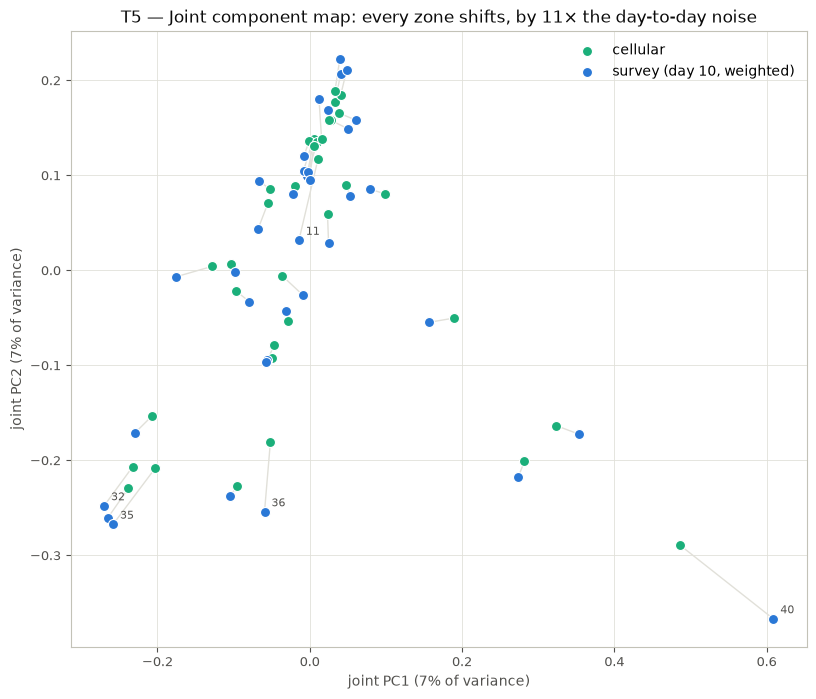

In [11]:
S = np.vstack([sz_cell.values, sz_s10.values])
pcJ = pca(S)
n = len(sz_cell)
sc_c, sc_s = pcJ['scores'][:n], pcJ['scores'][n:]

disp = np.linalg.norm(sz_s10.values - sz_cell.values, axis=1)
disp_days = np.linalg.norm(sz_s10.values - sz_s20.values, axis=1)
Dm = sz_s10.values - sz_cell.values
obs_shift = np.linalg.norm(Dm.mean(axis=0))
flips = rng.choice([-1., 1.], size=(10000, n))
null_shift = np.linalg.norm((flips[:, :, None] * Dm[None]).mean(axis=1), axis=1)
p_hi = (1 + (null_shift >= obs_shift).sum()) / 10001
self_diff = np.diag(sz_s10.values) - np.diag(sz_cell.values)
r_selfdiff = np.corrcoef(disp, np.abs(self_diff))[0, 1]

print(f"mean profile distance: survey vs cellular {disp.mean():.3f}, day 10 vs day 20 {disp_days.mean():.3f} "
      f"-> displacement ratio {disp.mean() / disp_days.mean():.1f}x")
print(f"mean self-containment: survey {np.diag(sz_s10.values).mean():.3f}, cellular {np.diag(sz_cell.values).mean():.3f}")
print(f"common-direction test: |mean difference| = {obs_shift:.4f}, sign-flip P(null >= obs) = {p_hi:.4f}")
print(f"  -> observed sits BELOW nearly the whole null: zone-specific, mutually cancelling divergence")
print(f"corr(per-zone displacement, |self-containment difference|) = {r_selfdiff:.3f}")

d2 = np.linalg.norm(sc_s[:, :2] - sc_c[:, :2], axis=1)
top = np.argsort(-d2)[:5]

fig, ax = plt.subplots(figsize=(9.5, 8), facecolor='white')
for i in range(n):
    ax.plot([sc_c[i, 0], sc_s[i, 0]], [sc_c[i, 1], sc_s[i, 1]],
            color=GRID, linewidth=1.0, zorder=1)
ax.scatter(sc_c[:, 0], sc_c[:, 1], s=52, color=AQUA, edgecolors='white',
           linewidths=0.8, zorder=2, label='cellular')
ax.scatter(sc_s[:, 0], sc_s[:, 1], s=52, color=BLUE, edgecolors='white',
           linewidths=0.8, zorder=2, label='survey (day 10, weighted)')
for i in top:
    ax.annotate(str(sz_ids[i]), (sc_s[i, 0], sc_s[i, 1]), textcoords='offset points',
                xytext=(5, 4), fontsize=8, color=INK2)
style_ax(ax,
         f'T5 — Joint component map: every zone shifts, by {disp.mean() / disp_days.mean():.0f}× the day-to-day noise',
         f"joint PC1 ({pcJ['evr'][0]:.0%} of variance)", f"joint PC2 ({pcJ['evr'][1]:.0%} of variance)")
ax.legend(frameon=False, fontsize=10)
save_show(fig, 'pca_joint_map.png')

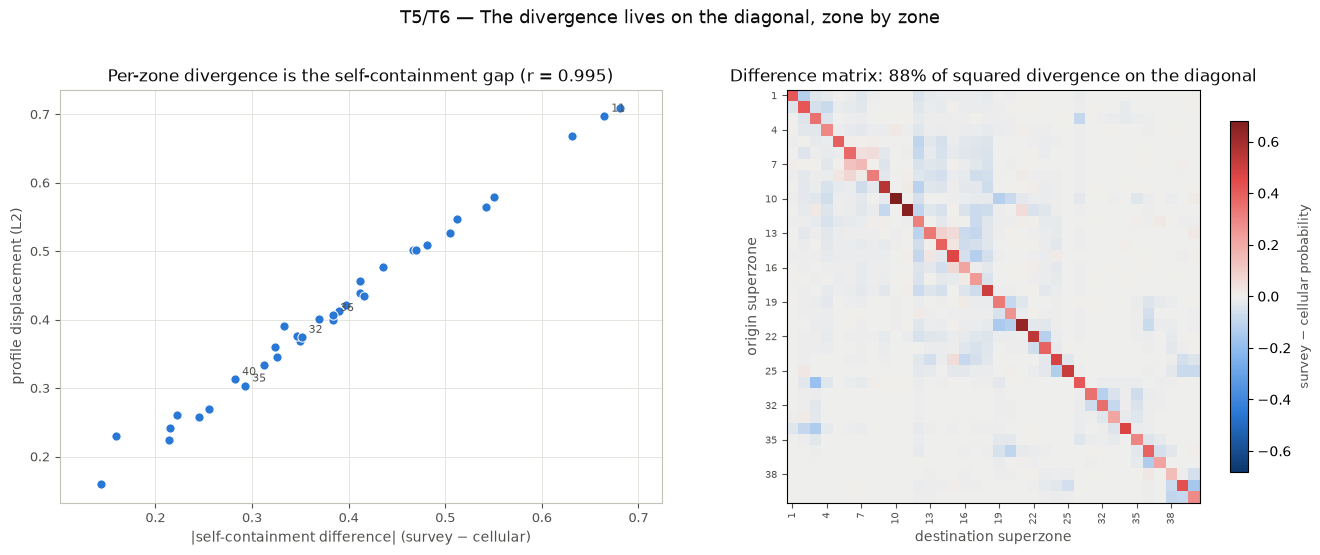

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.4), facecolor='white')

ax = axes[0]
ax.margins(x=0.08)
ax.scatter(np.abs(self_diff), disp, s=44, color=BLUE, edgecolors='white', linewidths=0.7)
for i in top[:5]:
    ax.annotate(str(sz_ids[i]), (abs(self_diff[i]), disp[i]), textcoords='offset points',
                xytext=(5, 3), fontsize=8, color=INK2)
style_ax(ax, f'Per-zone divergence is the self-containment gap (r = {r_selfdiff:.3f})',
         '|self-containment difference| (survey − cellular)', 'profile displacement (L2)')

ax = axes[1]
D = sz_s10.values - sz_cell.values
vmax = np.abs(D).max()
im = ax.imshow(D, cmap=CMAP_DIV, vmin=-vmax, vmax=vmax)
diag_share = (np.diag(D) ** 2).sum() / (D ** 2).sum()
ax.set_title(f'Difference matrix: {diag_share:.0%} of squared divergence on the diagonal',
             color=INK, fontsize=12)
step = 3
ax.set_xticks(range(0, n, step), sz_ids[::step], fontsize=7, rotation=90)
ax.set_yticks(range(0, n, step), sz_ids[::step], fontsize=7)
ax.set_xlabel('destination superzone', color=INK2, fontsize=10)
ax.set_ylabel('origin superzone', color=INK2, fontsize=10)
ax.tick_params(colors=INK2)
cb = fig.colorbar(im, ax=ax, shrink=0.85)
cb.set_label('survey − cellular probability', color=INK2, fontsize=9)
fig.suptitle('T5/T6 — The divergence lives on the diagonal, zone by zone', color=INK, fontsize=13, y=1.02)
plt.tight_layout()
save_show(fig, 'pca_divergence_structure.png')

## 7. T6 — Diagonal ablation: what remains once the intra-zone split is removed?

The known structural disagreement is self-containment (survey ≈ 72% of trips stay inside the origin superzone, cellular ≈ 34%). Here the diagonal is removed from every matrix, rows are re-normalized to pure *outbound* destination choices, and the T2/T3 statistics are recomputed — testing whether the sources also disagree about **where outbound trips go**, separately from *how many trips leave at all*.

SZ: diagonal share of squared divergence 0.880; diagonal removed (36 rows kept): overlap 0.672 (ceiling 0.943), RCEV 0.804 (ceiling 0.970)


TAZ: diagonal share of squared divergence 0.014; diagonal removed (622 rows kept): overlap 0.130 (ceiling 0.424), RCEV 0.310 (ceiling 0.634)


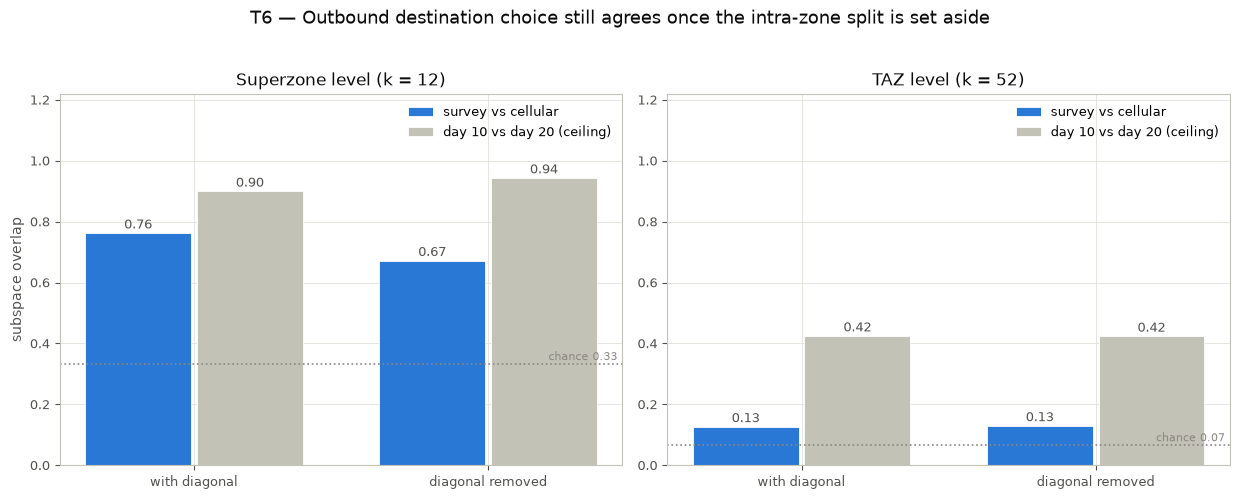

In [13]:
def strip_diag(P):
    A = np.asarray(P, float).copy()
    np.fill_diagonal(A, 0)
    rs = A.sum(axis=1, keepdims=True)
    ok = rs[:, 0] > 0
    A = np.divide(A, rs, out=np.zeros_like(A), where=rs > 0)
    return A, ok

ablation = {}
for lvl, P, k in [('SZ', P_SZ, kSZ), ('TAZ', P_TAZ, kTAZ)]:
    stripped = {name: strip_diag(v) for name, v in P.items()}
    ok = np.logical_and.reduce([s[1] for s in stripped.values()])
    Px = {name: s[0][ok] for name, s in stripped.items()}
    PCx = {name: pca(v) for name, v in Px.items()}
    ablation[lvl] = {
        'rows': int(ok.sum()),
        'overlap': mean_cos2(PCx['survey d10']['V'], PCx['cellular']['V'], k),
        'ceiling': mean_cos2(PCx['survey d10']['V'], PCx['survey d20']['V'], k),
        'rcev': rcev(Px['survey d10'], PCx['survey d10'], PCx['cellular'], k),
        'rcev_ceiling': rcev(Px['survey d20'], PCx['survey d20'], PCx['survey d10'], k),
    }
    D = P['survey d10'].values - P['cellular'].values
    diag_sh = (np.diag(D) ** 2).sum() / (D ** 2).sum()
    print(f"{lvl}: diagonal share of squared divergence {diag_sh:.3f}; "
          f"diagonal removed ({ablation[lvl]['rows']} rows kept): overlap {ablation[lvl]['overlap']:.3f} "
          f"(ceiling {ablation[lvl]['ceiling']:.3f}), RCEV {ablation[lvl]['rcev']:.3f} "
          f"(ceiling {ablation[lvl]['rcev_ceiling']:.3f})")

with_diag = {
    'SZ': (perm['SZ']['obs'], perm['SZ']['ceil']),
    'TAZ': (perm['TAZ']['obs'], perm['TAZ']['ceil']),
}

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), facecolor='white')
for ax, lvl, p, k in zip(axes, ['SZ', 'TAZ'], [36, 778], [kSZ, kTAZ]):
    groups = ['with diagonal', 'diagonal removed']
    surv = [with_diag[lvl][0], ablation[lvl]['overlap']]
    ceil = [with_diag[lvl][1], ablation[lvl]['ceiling']]
    x = np.arange(2)
    b1 = ax.bar(x - 0.19, surv, width=0.36, color=BLUE, edgecolor='white', linewidth=0.6,
                label='survey vs cellular')
    b2 = ax.bar(x + 0.19, ceil, width=0.36, color=AXIS, edgecolor='white', linewidth=0.6,
                label='day 10 vs day 20 (ceiling)')
    for bars in (b1, b2):
        for b in bars:
            ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.015, f'{b.get_height():.2f}',
                    ha='center', color=INK2, fontsize=9)
    ax.axhline(k / p, color=MUTED, linewidth=1.2, linestyle=':')
    ax.text(1.44, k / p + 0.012, f'chance {k / p:.2f}', color=MUTED, fontsize=8, ha='right')
    ax.set_xticks(x, groups)
    ax.set_ylim(0, 1.22)
    style_ax(ax, f"{'Superzone' if lvl == 'SZ' else 'TAZ'} level (k = {k})", None,
             'subspace overlap' if lvl == 'SZ' else None)
    ax.legend(frameon=False, fontsize=9, loc='upper right')
fig.suptitle('T6 — Outbound destination choice still agrees once the intra-zone split is set aside',
             color=INK, fontsize=13, y=1.03)
plt.tight_layout()
save_show(fig, 'pca_diagonal_ablation.png')

## 8. Findings

**1. The two matrices are built from the same dominant destination-choice patterns — far beyond chance.** At superzone level the top-12 subspaces overlap at **0.76** (chance 0.33; the permuted-geography null never exceeds 0.53 in 2,000 permutations, p ≈ 0.0005), against a day-10-vs-day-20 ceiling of 0.90. Cross-projection says the same thing more concretely: cellular's 12 components capture **93%** of the variance the survey's own 12 components capture (ceiling 99%), and survey components capture 89% of cellular's. The structural agreement is roughly 85% of what the survey achieves against itself.

**2. The same two leading patterns exist in both sources — in swapped order of importance.** Hungarian-matched Tucker congruences pair survey PC1 ↔ cellular PC2 (|φ| = 0.95) and survey PC2 ↔ cellular PC1 (|φ| = 0.89); four of six matched pairs exceed 0.82. The shared axes are (a) a **self-containment axis** (cellular PC1, score–self-containment r = +0.76; survey PC2, r = −0.76) and (b) a **north–south geographic axis** contrasting superzones 38–40/25 against 31–35. The swap is diagnostic: in the cellular data self-containment *varies* across origins (its #1 source of variance), while in the survey almost every origin is uniformly self-contained (72% on average), leaving the geographic axis as its #1 pattern.

**3. The divergence is zone-specific self-containment reallocation, not a common bias direction.** Every zone's survey profile sits ~**11×** further from its cellular profile than day-to-day survey noise, and per-zone displacement is almost perfectly explained by the self-containment gap (r = 0.995). The sign-flip test *rejects a shared direction*: the observed mean-difference vector is shorter than in ~99.7% of random sign assignments — the differences cancel across zones because each zone moves mass between its **own** diagonal cell and its off-diagonal row, rather than all zones shifting toward or away from a common destination. Consistently, **88%** of the squared superzone divergence lies on the diagonal.

**4. Off-diagonal destination choice agrees on its own, though a shared diagonal inflated the headline overlap.** With diagonals removed and rows re-normalized to outbound choices, superzone overlap reads 0.67 against a 0.94 ceiling (chance 0.33) and RCEV 0.80 (ceiling 0.97) — genuine, above-chance agreement on *where outbound trips go*, somewhat weaker than the with-diagonal figures because diagonal dominance is itself structure the two sources shared.

**5. At TAZ level, PCA confirms that sparsity — not structure — drives disagreement.** The survey's effective dimensionality explodes (participation ratio ≈ 249 vs 42 for cellular), and even the two survey days only overlap at 0.43 (k = 52) — the survey cannot replicate its *own* TAZ-level component structure across days, so its 0.13 overlap with cellular (p = 0.002, still above chance) is bounded by sampling noise, echoing the r ≈ 0.29-vs-0.86 scale effect found in the correlation analysis.

**Implication for the pipeline.** The PCA evidence supports the fusion design already adopted: the two sources agree on the dominant spatial patterns at the scale where the survey is estimable (superzones), disagree essentially *only* on the intra-zone diagonal — the exact quantity the EB-shrunk superzone correction factors act on — and the survey carries no usable TAZ-level pattern structure of its own, justifying cellular as the TAZ-scale prior.